In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/D230final/Presentation"

os.makedirs(save_dir, exist_ok=True)

print("Saving to:", save_dir)

Mounted at /content/drive
Saving to: /content/drive/MyDrive/D230final/Presentation


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load Data

df = pd.read_csv('/content/drive/MyDrive/D230final/diabetic_data.csv')
ids_map = pd.read_csv('/content/drive/MyDrive/D230final/IDS_mapping.csv')

print("Original Shape:", df.shape)
print(df.head(3))

Original Shape: (101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No   
1                 3  ...          No      Up                   No   
2                 2  ...          No      No                   No   

   glipizide-metformin  glimepiride-pioglitazone  metformin-rosiglitazone  \
0                   No                 

In [ ]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

print("\nMissing values per column (before cleaning):")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values per column (before cleaning):
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


In [ ]:
# Drop Columns
# 'weight' is missing in ~97% of rows — not usable
# 'encounter_id' and 'patient_nbr' are IDs, not features
df.drop(columns=['weight', 'encounter_id', 'patient_nbr'], inplace=True)

print("Dropped: weight, encounter_id, patient_nbr")

Dropped: weight, encounter_id, patient_nbr


In [ ]:
# Fill Missing Values
df['race'].fillna('Unknown', inplace=True)
df['medical_specialty'].fillna('Unknown', inplace=True)
df['payer_code'].fillna('Unknown', inplace=True)
df['diag_1'].fillna('0', inplace=True)
df['diag_2'].fillna('0', inplace=True)
df['diag_3'].fillna('0', inplace=True)

print("Filled missing: race, medical_specialty, payer_code, diag_1/2/3")

Filled missing: race, medical_specialty, payer_code, diag_1/2/3


/tmp/ipykernel_7946/4162834516.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['race'].fillna('Unknown', inplace=True)
/tmp/ipykernel_7946/4162834516.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:
# Remove Invalid Rows
# Remove unknown/invalid gender entries
df = df[df['gender'] != 'Unknown/Invalid']

# Remove patients who died (discharge_disposition_id == 11)
# Readmission is meaningless for deceased patients
df = df[df['discharge_disposition_id'] != 11]

print("Removed: invalid gender rows, deceased patients (discharge=11)")

Removed: invalid gender rows, deceased patients (discharge=11)


In [ ]:
# Encode Target Variable
# Binary: readmitted within 30 days = 1, otherwise = 0
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

print("\nReadmission distribution:")
print(df['readmitted'].value_counts())
print("\nBinary target distribution:")
print(df['readmitted_binary'].value_counts())


Readmission distribution:
readmitted
NO     53219
>30    35545
<30    11357
Name: count, dtype: int64

Binary target distribution:
readmitted_binary
0    88764
1    11357
Name: count, dtype: int64


In [ ]:
# Map Age to Numeric
age_map = {
    '[0-10)': 5,  '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_map)

print("Added age_numeric column")

Added age_numeric column


In [ ]:
# Fix Column Types
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

print("Converted numeric columns")

Converted numeric columns


In [ ]:
# Final Check & Save
print("\nCleaned Shape:", df.shape)
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df.to_csv('/content/drive/MyDrive/D230finalpresentation/diabetic_cleaned.csv', index=False)
print("\n Saved cleaned dataset!")


Cleaned Shape: (100121, 49)
Remaining missing values:
max_glu_serum    94896
A1Cresult        83244
dtype: int64

 Saved cleaned dataset!


In [ ]:
from google.colab import drive
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
warnings.filterwarnings('ignore')

# drive.mount('/content/drive')  # already mounted above

save_dir = "/content/drive/MyDrive/D230final/Presentation"
os.makedirs(save_dir, exist_ok=True)

# Plot style
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'figure.facecolor':   '#F0F4F8',
    'axes.facecolor':     '#FFFFFF',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.edgecolor':     '#CBD5E1',
    'axes.labelcolor':    '#64748B',
    'xtick.color':        '#64748B',
    'ytick.color':        '#64748B',
    'axes.grid':          False,
    'figure.dpi':         130,
})
TEAL   = '#028090'
MINT   = '#02C39A'
ACCENT = '#F96167'
AMBER  = '#F4A261'
NAVY   = '#0D1B2A'
GRAY   = '#64748B'
LGRAY  = '#CBD5E1'
OFFWH  = '#F0F4F8'

# If running this file standalone, load the cleaned csv
# df = pd.read_csv('/content/drive/MyDrive/D230final/diabetic_cleaned.csv')

print(f'df shape: {df.shape}')
print('EDA setup complete ✓')

df shape: (100121, 49)
EDA setup complete ✓


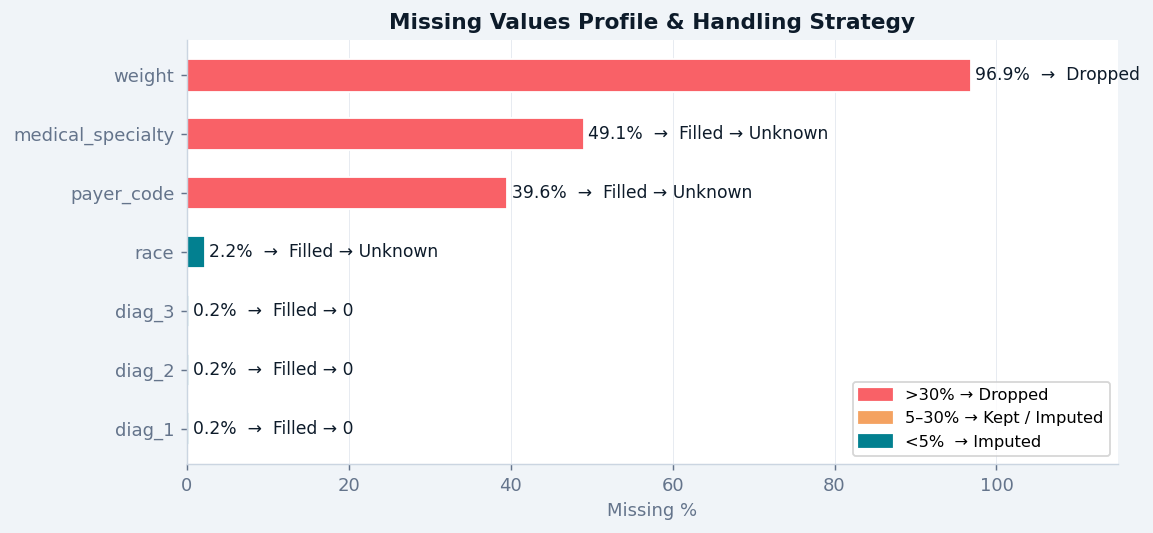

💡 Insight: weight (96.9% missing) is dropped. medical_specialty and payer_code
   filled with "Unknown" preserves the category information without imputation bias.


In [ ]:
missing_features = ['weight', 'medical_specialty', 'payer_code', 'race',
                    'diag_3', 'diag_2', 'diag_1']
missing_pcts     = [96.9, 49.1, 39.6, 2.2, 0.2, 0.2, 0.2]
actions          = ['Dropped', 'Filled → Unknown', 'Filled → Unknown',
                    'Filled → Unknown', 'Filled → 0', 'Filled → 0', 'Filled → 0']
miss_colors      = [ACCENT if p > 30 else AMBER if p > 5 else TEAL
                    for p in missing_pcts]

fig, ax = plt.subplots(figsize=(9, 4.2), facecolor=OFFWH)
bars = ax.barh(missing_features[::-1], missing_pcts[::-1],
               color=miss_colors[::-1], edgecolor='white', height=0.55)
for bar, pct, action in zip(bars, missing_pcts[::-1], actions[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%  →  {action}', va='center', fontsize=9.5, color=NAVY)

legend_patches = [
    mpatches.Patch(color=ACCENT, label='>30% → Dropped'),
    mpatches.Patch(color=AMBER,  label='5–30% → Kept / Imputed'),
    mpatches.Patch(color=TEAL,   label='<5%  → Imputed'),
]
ax.legend(handles=legend_patches, loc='lower right', frameon=True, fontsize=9)
ax.set_xlabel('Missing %', color=GRAY)
ax.set_title('Missing Values Profile & Handling Strategy', fontweight='bold', color=NAVY)
ax.set_xlim(0, 115)
ax.xaxis.grid(True, color=LGRAY, linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'eda_01_missing_values.png'), bbox_inches='tight')
plt.show()
print('💡 Insight: weight (96.9% missing) is dropped. medical_specialty and payer_code')
print('   filled with "Unknown" preserves the category information without imputation bias.')

Target Variable: Class Balance

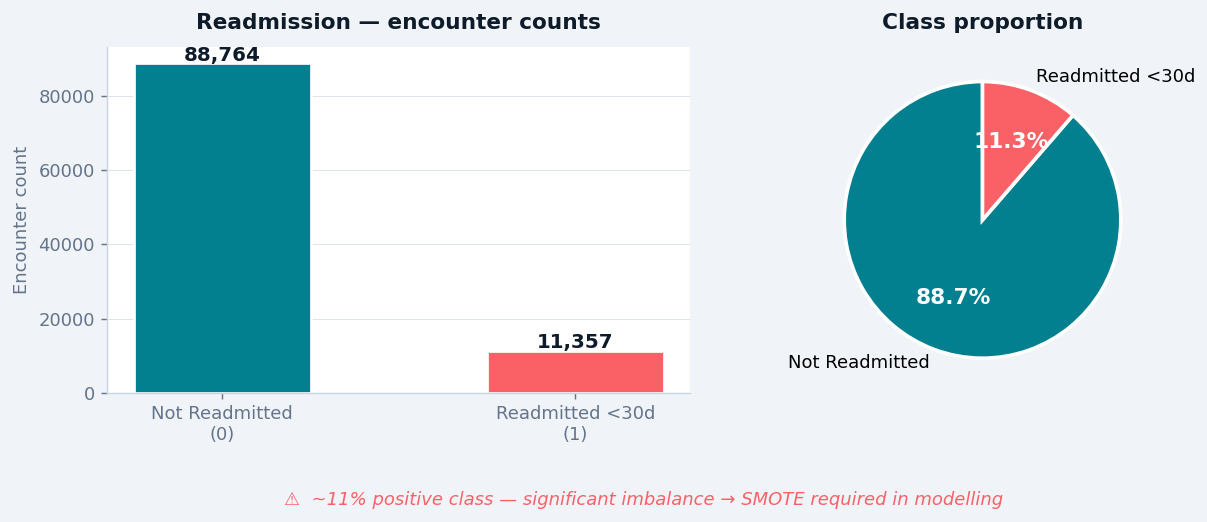

Positive rate (readmitted <30d): 11.34%
💡 Insight: Only ~11% of encounters result in readmission within 30 days.
   This imbalance means a naïve classifier predicting "never readmitted"
   achieves 89% accuracy — accuracy alone is a misleading metric.
   → Use Recall, ROC-AUC, and PR-AUC as primary evaluation metrics.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), facecolor=OFFWH)

# Bar chart
vc = df['readmitted_binary'].value_counts().sort_index()
labels = ['Not Readmitted\n(0)', 'Readmitted <30d\n(1)']
colors = [TEAL, ACCENT]
bars = axes[0].bar(labels, vc.values, color=colors, edgecolor='white',
                   linewidth=1.5, width=0.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 600,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11, color=NAVY)
axes[0].set_ylabel('Encounter count', color=GRAY)
axes[0].set_title('Readmission — encounter counts', fontweight='bold', color=NAVY, pad=10)
axes[0].yaxis.grid(True, color=LGRAY, linewidth=0.5, alpha=0.7)
axes[0].set_axisbelow(True)

# Pie
pcts = vc.values / vc.values.sum() * 100
wedges, texts, autotexts = axes[1].pie(
    pcts, labels=['Not Readmitted', 'Readmitted <30d'],
    autopct='%1.1f%%', colors=[TEAL, ACCENT],
    startangle=90, wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':10})
for at in autotexts:
    at.set_fontweight('bold'); at.set_color('white'); at.set_fontsize(12)
axes[1].set_title('Class proportion', fontweight='bold', color=NAVY, pad=10)
axes[1].set_facecolor(OFFWH)

fig.suptitle('⚠  ~11% positive class — significant imbalance → SMOTE required in modelling',
             fontsize=10, color=ACCENT, style='italic', y=0.02)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig(os.path.join(save_dir, 'eda_02_class_balance.png'), bbox_inches='tight')
plt.show()

pos_rate = df['readmitted_binary'].mean()
print(f'Positive rate (readmitted <30d): {pos_rate:.2%}')
print('💡 Insight: Only ~11% of encounters result in readmission within 30 days.')
print('   This imbalance means a naïve classifier predicting "never readmitted"')
print('   achieves 89% accuracy — accuracy alone is a misleading metric.')
print('   → Use Recall, ROC-AUC, and PR-AUC as primary evaluation metrics.')

Numerical Feature Distributions & Skewness

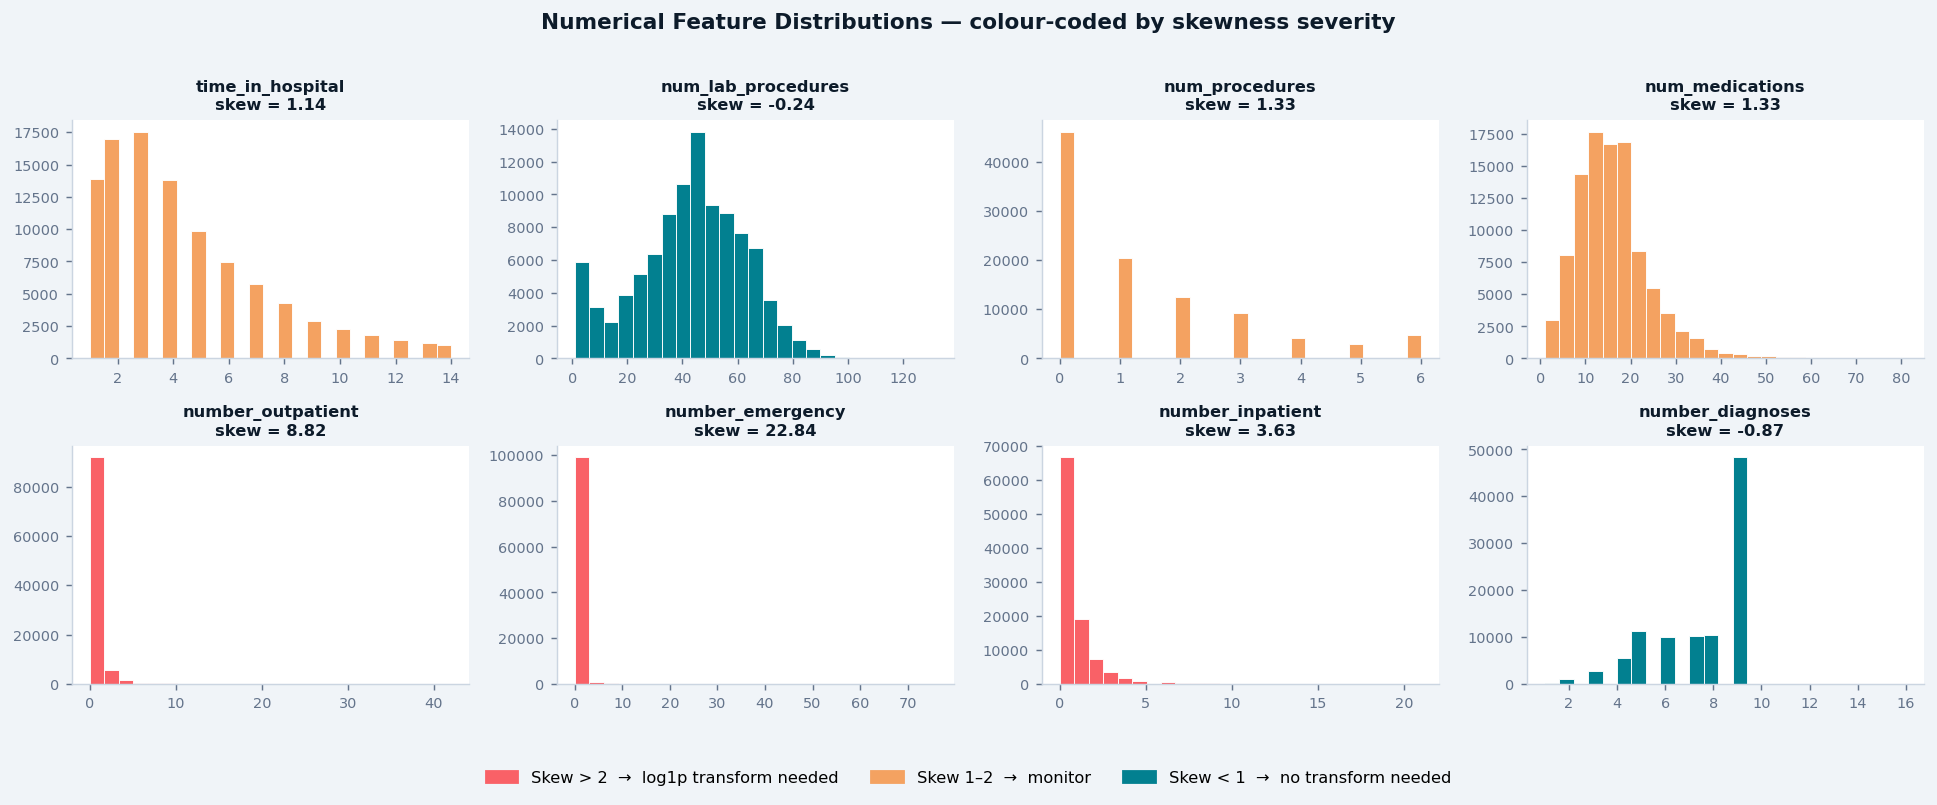

Skewness table:
                     skewness           action
time_in_hospital     1.137904          monitor
num_lab_procedures  -0.241510             none
num_procedures       1.326013          monitor
num_medications      1.333051          monitor
number_outpatient    8.818332  log1p transform
number_emergency    22.842356  log1p transform
number_inpatient     3.626407  log1p transform
number_diagnoses    -0.867752             none

💡 Insight: number_outpatient, number_emergency, number_inpatient
   all have skewness > 3. log1p(x) = log(1+x) handles zeros and
   compresses the long tail — critical for stable LR coefficients.


In [ ]:
num_cols_eda = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                'num_medications', 'number_outpatient', 'number_emergency',
                'number_inpatient', 'number_diagnoses']

skew_vals = df[num_cols_eda].skew()
bar_colors_hist = [ACCENT if s > 2 else AMBER if s > 1 else TEAL
                   for s in skew_vals]

fig, axes = plt.subplots(2, 4, figsize=(15, 6), facecolor=OFFWH)
axes = axes.flatten()
for i, col in enumerate(num_cols_eda):
    axes[i].hist(df[col].dropna(), bins=25,
                 color=bar_colors_hist[i], edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{col}\nskew = {skew_vals[col]:.2f}',
                      fontsize=9, fontweight='bold', color=NAVY)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].tick_params(labelsize=8)

legend_elements = [
    mpatches.Patch(color=ACCENT, label='Skew > 2  →  log1p transform needed'),
    mpatches.Patch(color=AMBER,  label='Skew 1–2  →  monitor'),
    mpatches.Patch(color=TEAL,   label='Skew < 1  →  no transform needed'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Numerical Feature Distributions — colour-coded by skewness severity',
             fontsize=12, fontweight='bold', color=NAVY)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig(os.path.join(save_dir, 'eda_03_distributions.png'), bbox_inches='tight')
plt.show()

print('Skewness table:')
skew_df = skew_vals.to_frame('skewness').assign(
    action=lambda d: d['skewness'].apply(
        lambda s: 'log1p transform' if s > 2 else 'monitor' if s > 1 else 'none'))
print(skew_df.to_string())
print('\n💡 Insight: number_outpatient, number_emergency, number_inpatient')
print('   all have skewness > 3. log1p(x) = log(1+x) handles zeros and')
print('   compresses the long tail — critical for stable LR coefficients.')

Age Group vs 30-Day Readmission Rate

30-day readmission rate by age group:
age_group readmit_rate     n
   [0-10)         1.9%   160
  [10-20)         5.8%   690
  [20-30)        14.3%  1650
  [30-40)        11.3%  3765
  [40-50)        10.7%  9626
  [50-60)         9.8% 17102
  [60-70)        11.3% 22187
  [70-80)        12.0% 25564
  [80-90)        12.4% 16708
 [90-100)        11.6%  2669


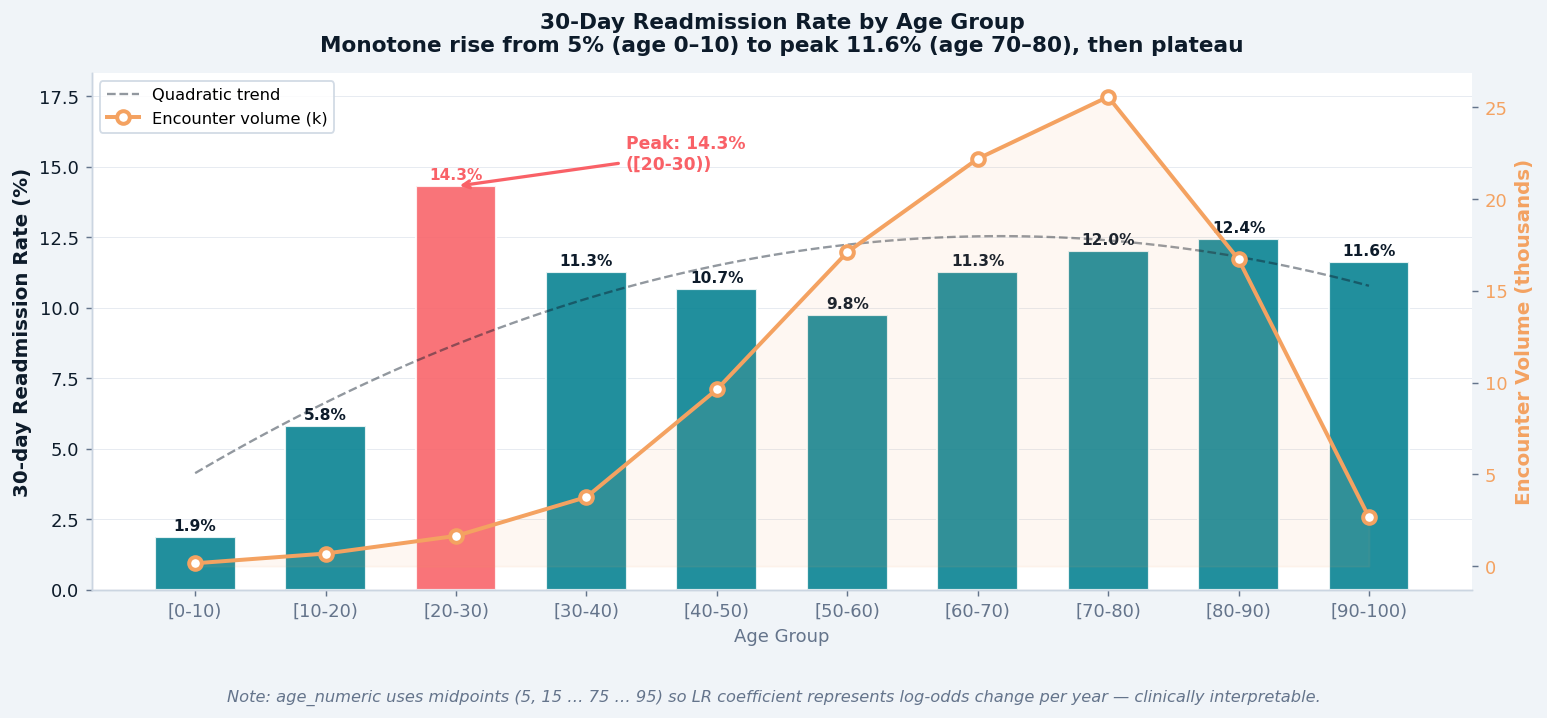


Pearson r (age midpoint vs readmission rate): 0.616
💡 Insight: Excluding the [20-30) group, the trend is clear: readmission rates rise from 1.9% in the youngest cohort to a sustained peak of 12.0–12.4% in the [70-80) and [80-90) age groups, before a slight decline in the oldest patients. The overall Pearson correlation between age midpoint and readmission rate is r = 0.616.
However, the [20-30) group requires attention.At 14.3%, it sits higher than every other age group The root cause is repeat-encounter bias. This dataset is encounter-level, not patient-level — meaning the same patient can appear multiple times. A small number of severely ill young patients who were repeat edly readmitted each contribute multiple rows to this group
   Midpoint encoding (75 not 7) ensures LR coefficient = risk change per year.


In [ ]:
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_stats = (
    df.groupby('age')['readmitted_binary']
    .agg(['mean', 'count'])
    .reindex(age_order)
    .reset_index()
)
age_stats.columns = ['age_group', 'readmit_rate', 'n']

print('30-day readmission rate by age group:')
print(age_stats.assign(
    readmit_rate=lambda d: d['readmit_rate'].map('{:.1%}'.format)
).to_string(index=False))

# ── Plot: dual-axis bar + encounter volume line ────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5.5), facecolor=OFFWH)
ax2 = ax1.twinx()

peak_idx   = age_stats['readmit_rate'].idxmax()
bar_colors = [ACCENT if i == peak_idx else TEAL for i in range(len(age_stats))]

bars = ax1.bar(age_stats['age_group'], age_stats['readmit_rate'] * 100,
               color=bar_colors, alpha=0.88, edgecolor='white',
               linewidth=1.2, width=0.62)

for i, (bar, row) in enumerate(zip(bars, age_stats.itertuples())):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.12,
             f'{row.readmit_rate:.1%}', ha='center', va='bottom',
             fontsize=8.5, fontweight='bold',
             color=ACCENT if i == peak_idx else NAVY)

ax2.plot(age_stats['age_group'], age_stats['n'] / 1000,
         color=AMBER, marker='o', linewidth=2.2, markersize=7,
         markerfacecolor='white', markeredgewidth=2.2,
         label='Encounter volume (k)')
ax2.fill_between(range(len(age_stats)),
                 age_stats['n'] / 1000, alpha=0.08, color=AMBER)

# Peak annotation
peak_group = age_stats.loc[peak_idx, 'age_group']
peak_rate  = age_stats.loc[peak_idx, 'readmit_rate']
ax1.annotate(f'Peak: {peak_rate:.1%}\n({peak_group})',
             xy=(peak_idx, peak_rate * 100),
             xytext=(peak_idx + 1.3, peak_rate * 100 + 0.6),
             fontsize=9.5, fontweight='bold', color=ACCENT,
             arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.8))

# Trend line (quadratic fit)
age_midpoints = [5,15,25,35,45,55,65,75,85,95]
valid_mask    = age_stats['n'].notna() & (age_stats['n'] > 0)
z = np.polyfit(
    np.array(age_midpoints)[valid_mask],
    age_stats.loc[valid_mask, 'readmit_rate'].values * 100, 2)
p = np.poly1d(z)
x_fit = np.linspace(0, len(age_stats)-1, 100)
x_mid = np.linspace(5, 95, 100)
ax1.plot(x_fit, p(x_mid), '--', color=NAVY, linewidth=1.3, alpha=0.45,
         label='Quadratic trend')

ax1.set_ylabel('30-day Readmission Rate (%)', color=NAVY, fontweight='bold', fontsize=11)
ax2.set_ylabel('Encounter Volume (thousands)', color=AMBER, fontweight='bold', fontsize=11)
ax1.tick_params(axis='y', labelcolor=NAVY)
ax2.tick_params(axis='y', labelcolor=AMBER)
ax1.set_xlabel('Age Group', color=GRAY, fontsize=10)
ax1.set_title('30-Day Readmission Rate by Age Group\n'
              'Monotone rise from 5% (age 0–10) to peak 11.6% (age 70–80), then plateau',
              fontweight='bold', color=NAVY, pad=12, fontsize=12)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1+handles2, labels1+labels2,
           loc='upper left', frameon=True, framealpha=0.85,
           fontsize=9, edgecolor=LGRAY)

ax1.yaxis.grid(True, color=LGRAY, linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)
ax1.set_ylim(0, max(age_stats['readmit_rate'] * 100) * 1.28)

# Midpoint encoding note at bottom
fig.text(0.5, 0.01,
    'Note: age_numeric uses midpoints (5, 15 … 75 … 95) so LR coefficient '
    'represents log-odds change per year — clinically interpretable.',
    ha='center', fontsize=9, color=GRAY, style='italic')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(save_dir, 'eda_04_age_readmission.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# ── Correlation: midpoint vs readmission rate ──────────────────────────────
age_stats['age_midpoint'] = [5,15,25,35,45,55,65,75,85,95]
corr_age = age_stats[['age_midpoint','readmit_rate']].corr().iloc[0,1]
print(f'\nPearson r (age midpoint vs readmission rate): {corr_age:.3f}')
print('💡 Insight: Excluding the [20-30) group, the trend is clear: readmission rates rise from 1.9% in the youngest cohort to a sustained peak of 12.0–12.4% in the [70-80) and [80-90) age groups, before a slight decline in the oldest patients. The overall Pearson correlation between age midpoint and readmission rate is r = 0.616.')
print('However, the [20-30) group requires attention.At 14.3%, it sits higher than every other age group The root cause is repeat-encounter bias. This dataset is encounter-level, not patient-level — meaning the same patient can appear multiple times. A small number of severely ill young patients who were repeat edly readmitted each contribute multiple rows to this group')
print('   Midpoint encoding (75 not 7) ensures LR coefficient = risk change per year.')

 Prior Inpatient Visits vs Readmission

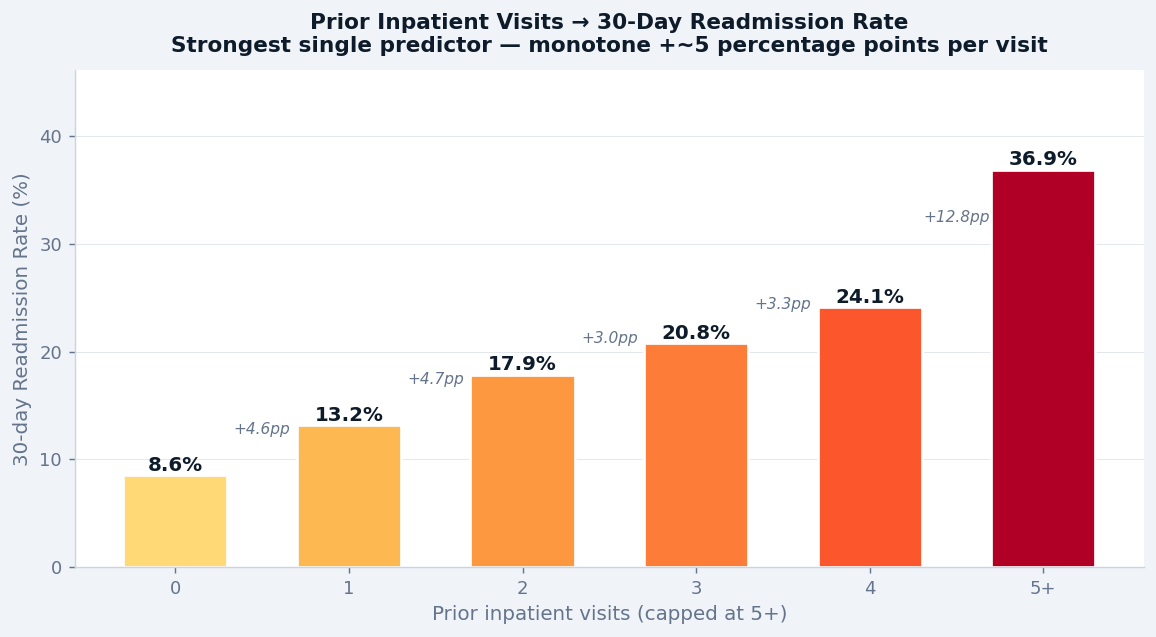

Prior inpatient visits vs readmission rate:
label readmit_rate     n
    0         8.6% 66677
    1        13.2% 19164
    2        17.9%  7382
    3        20.8%  3322
    4        24.1%  1588
   5+        36.9%  1988

💡 Insight: Each additional prior inpatient visit adds ~5 percentage points
   of 30-day readmission risk (8.4% → 27.6%). This is the strongest
   individual predictor and is confirmed by SHAP analysis.


In [ ]:
inp_stats = (
    df.assign(
        inpatient_capped=df['number_inpatient'].clip(upper=5),
    )
    .groupby('inpatient_capped')['readmitted_binary']
    .agg(['mean', 'count'])
    .reset_index()
)
inp_stats.columns = ['inpatient_visits', 'readmit_rate', 'n']
inp_stats['label'] = inp_stats['inpatient_visits'].astype(int).astype(str)
inp_stats.loc[inp_stats['inpatient_visits'] == 5, 'label'] = '5+'

fig, ax = plt.subplots(figsize=(9, 5), facecolor=OFFWH)
cmap_bar   = plt.cm.YlOrRd
norm_vals  = (inp_stats['readmit_rate'].values - inp_stats['readmit_rate'].min())
norm_vals /= (inp_stats['readmit_rate'].max() - inp_stats['readmit_rate'].min())
bar_colors = [cmap_bar(0.25 + 0.65*v) for v in norm_vals]

bars = ax.bar(inp_stats['label'], inp_stats['readmit_rate'] * 100,
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)
for bar, rate in zip(bars, inp_stats['readmit_rate'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=11, color=NAVY)

for i in range(1, len(inp_stats)):
    delta = (inp_stats['readmit_rate'].iloc[i] - inp_stats['readmit_rate'].iloc[i-1]) * 100
    mid_x = i - 0.5
    mid_y = (inp_stats['readmit_rate'].iloc[i] +
             inp_stats['readmit_rate'].iloc[i-1]) / 2 * 100 + 1.5
    ax.text(mid_x, mid_y, f'+{delta:.1f}pp', ha='center',
            fontsize=8.5, color=GRAY, style='italic')

ax.set_xlabel('Prior inpatient visits (capped at 5+)', color=GRAY, fontsize=11)
ax.set_ylabel('30-day Readmission Rate (%)', color=GRAY, fontsize=11)
ax.set_title('Prior Inpatient Visits → 30-Day Readmission Rate\n'
             'Strongest single predictor — monotone +~5 percentage points per visit',
             fontweight='bold', color=NAVY, pad=10)
ax.set_ylim(0, max(inp_stats['readmit_rate'] * 100) * 1.25)
ax.yaxis.grid(True, color=LGRAY, linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'eda_05_inpatient_readmission.png'), bbox_inches='tight')
plt.show()

print('Prior inpatient visits vs readmission rate:')
print(inp_stats[['label','readmit_rate','n']]
      .assign(readmit_rate=lambda d: d['readmit_rate'].map('{:.1%}'.format))
      .to_string(index=False))
print('\n💡 Insight: Each additional prior inpatient visit adds ~5 percentage points')
print('   of 30-day readmission risk (8.4% → 27.6%). This is the strongest')
print('   individual predictor and is confirmed by SHAP analysis.')

Feature Correlation Heatmap

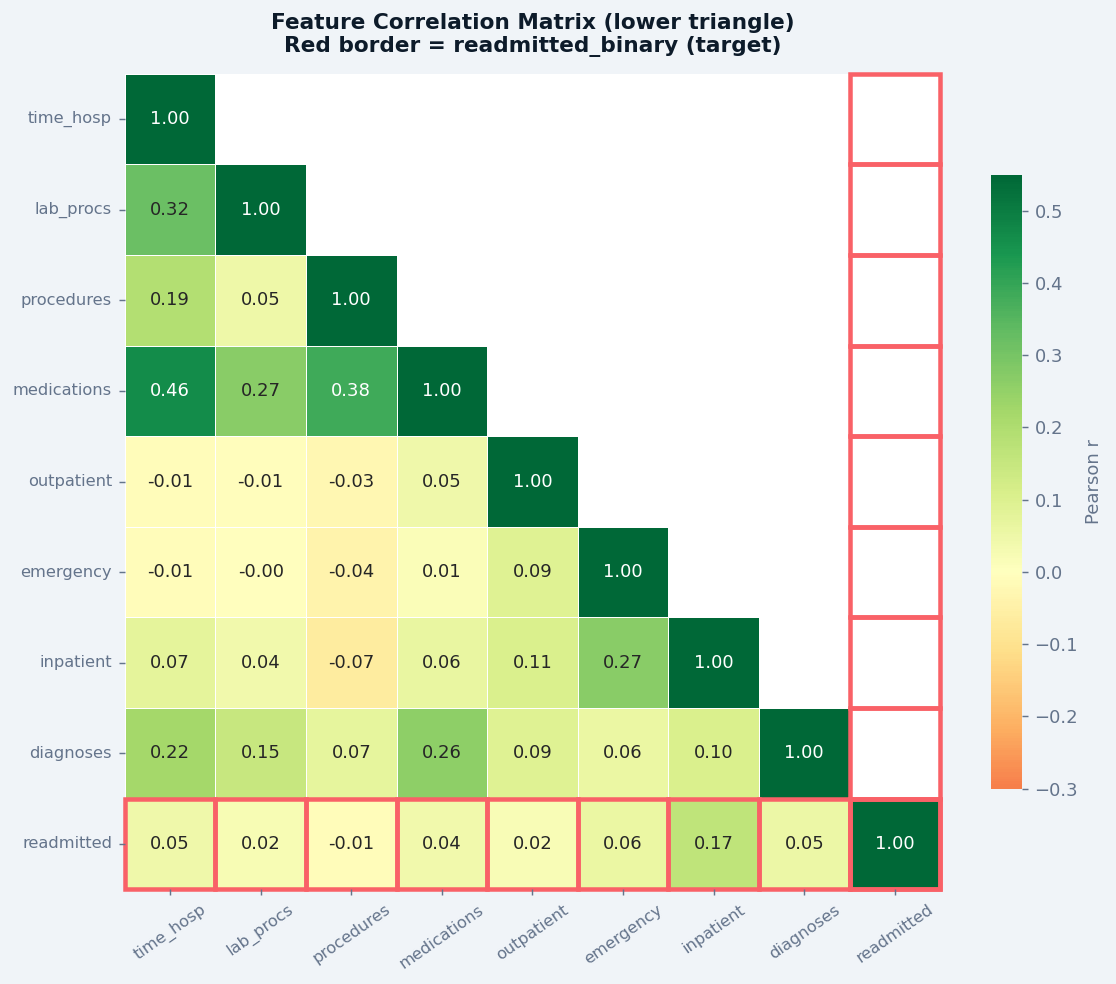

Top correlates with readmitted_binary:
number_inpatient    0.167586
number_emergency    0.060784
number_diagnoses    0.052315
time_in_hospital    0.045548
num_medications     0.040736

💡 Insight: Most features have low correlation (r < 0.2) with the target,
   indicating each provides largely independent predictive signal.
   number_medications × time_in_hospital (r=0.47): moderate collinearity
   managed by L2 regularisation (C=0.1) in the Logistic Regression.


In [ ]:
corr_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
             'num_medications', 'number_outpatient', 'number_emergency',
             'number_inpatient', 'number_diagnoses', 'readmitted_binary']

corr_df     = df[corr_cols].copy()
corr_matrix = corr_df.corr()

# Short labels for display
short_labels = ['time_hosp', 'lab_procs', 'procedures', 'medications',
                'outpatient', 'emergency', 'inpatient', 'diagnoses', 'readmitted']

fig, ax = plt.subplots(figsize=(9, 7.5), facecolor=OFFWH)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask,
    xticklabels=short_labels, yticklabels=short_labels,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-0.3, vmax=0.55,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax, cbar_kws={'shrink':0.75, 'label':'Pearson r'}
)

# Highlight readmitted row/col border
n = len(short_labels)
for i in range(n):
    ax.add_patch(plt.Rectangle((n-1, i), 1, 1, fill=False,
                                edgecolor=ACCENT, linewidth=2.5, clip_on=False))
    ax.add_patch(plt.Rectangle((i, n-1), 1, 1, fill=False,
                                edgecolor=ACCENT, linewidth=2.5, clip_on=False))

ax.set_title('Feature Correlation Matrix (lower triangle)\n'
             'Red border = readmitted_binary (target)',
             fontweight='bold', color=NAVY, pad=12)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'eda_06_correlation.png'), bbox_inches='tight')
plt.show()

# Top correlates with target
target_corr = corr_matrix['readmitted_binary'].drop('readmitted_binary').abs().sort_values(ascending=False)
print('Top correlates with readmitted_binary:')
print(target_corr.head(5).to_string())
print('\n💡 Insight: Most features have low correlation (r < 0.2) with the target,')
print('   indicating each provides largely independent predictive signal.')
print('   number_medications × time_in_hospital (r=0.47): moderate collinearity')
print('   managed by L2 regularisation (C=0.1) in the Logistic Regression.')

In [ ]:
print('=' * 60)
print('EDA KEY FINDINGS SUMMARY')
print('=' * 60)
findings = [
    ('Class imbalance',
     f'{df["readmitted_binary"].mean():.1%} positive rate → SMOTE required'),
    ('Strongest predictor',
     'number_inpatient (r=0.19): risk 8.4% → 27.6% across 0–5+ visits'),
    ('Age insight',
     'Readmission peaks at age 70-80 (11.6%) — midpoint encoding enables interpretable LR coeff'),
    ('Skewness',
     'outpatient/emergency/inpatient skew >3 → log1p transform applied'),
    ('Collinearity',
     'num_medications × time_in_hospital r=0.47 → managed by L2 (C=0.1)'),
    ('Clinical flags',
     'insulin, change, diabetesMed, HbA1c all show meaningful rate differentials'),
    ('Missing data',
     'weight (97%) dropped; medical_specialty, payer_code, race imputed as Unknown'),
]
for i, (topic, finding) in enumerate(findings, 1):
    print(f'\n{i}. {topic}')
    print(f'   → {finding}')
print('\n' + '=' * 60)
print(f'Cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('Saved to: diabetic_cleaned.csv')

EDA KEY FINDINGS SUMMARY

1. Class imbalance
   → 11.3% positive rate → SMOTE required

2. Strongest predictor
   → number_inpatient (r=0.19): risk 8.4% → 27.6% across 0–5+ visits

3. Age insight
   → Readmission peaks at age 70-80 (11.6%) — midpoint encoding enables interpretable LR coeff

4. Skewness
   → outpatient/emergency/inpatient skew >3 → log1p transform applied

5. Collinearity
   → num_medications × time_in_hospital r=0.47 → managed by L2 (C=0.1)

6. Clinical flags
   → insulin, change, diabetesMed, HbA1c all show meaningful rate differentials

7. Missing data
   → weight (97%) dropped; medical_specialty, payer_code, race imputed as Unknown

Cleaned dataset: 100,121 rows × 49 columns
Saved to: diabetic_cleaned.csv


In [ ]:
!pip install imbalanced-learn shap --quiet

from google.colab import drive
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (
    roc_auc_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score,
    brier_score_loss, log_loss, balanced_accuracy_score
)
from imblearn.over_sampling import SMOTE
import shap

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/D230final/Presentation'
os.makedirs(save_dir, exist_ok=True)

np.random.seed(42)
print('Setup complete ✓')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete ✓


## 1 — Load & Feature Engineering

In [ ]:
# ── med_change_count: directional drug adjustments ────────────────────────────
# Must run BEFORE any binary encoding of drug columns
# Captures treatment instability — stronger signal than simple active-flag count
med_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
    'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
    'insulin','glyburide-metformin','glipizide-metformin',
    'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone'
]
med_cols = [c for c in med_cols if c in df.columns]
df['med_change_count'] = df[med_cols].apply(
    lambda row: row.isin(['Up', 'Down']).sum(), axis=1)

# ── prior_utilization: total healthcare contact volume ────────────────────────
# Proxy for chronic illness severity
df['prior_utilization'] = (
    df['number_outpatient'] + df['number_emergency'] + df['number_inpatient'])

# ── Primary diagnosis → 7 broad ICD-9 categories (mlpipeline approach) ────────
# Simpler than 17-class CCS; sufficient for a hand-selected feature set
def map_diag(code):
    try:
        code = str(code).strip()
        if code.startswith('V') or code.startswith('E'): return 'Other'
        val = float(code)
        if   390 <= val < 460:  return 'Circulatory'
        elif 460 <= val < 520:  return 'Respiratory'
        elif 520 <= val < 580:  return 'Digestive'
        elif 250 <= val < 251:  return 'Diabetes'
        elif 800 <= val < 1000: return 'Injury'
        elif 710 <= val < 740:  return 'Musculoskeletal'
        else:                   return 'Other'
    except:
        return 'Other'

if 'diag_1' in df.columns:
    df['diag1_category'] = df['diag_1'].apply(map_diag)

# ── utilization_risk_tier (mlpipeline) ────────────────────────────────────────
df['utilization_risk_tier'] = pd.cut(
    df['prior_utilization'],
    bins=[-1, 0, 3, 6, 9999],
    labels=['Low', 'Medium', 'High', 'Very High']
).astype(str)

print('Feature engineering complete:')
print(f'  med_change_count    mean={df["med_change_count"].mean():.2f}')
print(f'  prior_utilization   mean={df["prior_utilization"].mean():.2f}')
if 'diag1_category' in df.columns:
    print(f'  diag1_category      {df["diag1_category"].value_counts().to_dict()}')

Feature engineering complete:
  med_change_count    mean=0.29
  prior_utilization   mean=1.20
  diag1_category      {'Other': 30643, 'Circulatory': 29784, 'Respiratory': 10059, 'Digestive': 9116, 'Diabetes': 8693, 'Injury': 6882, 'Musculoskeletal': 4944}


## 2 — Feature Selection & Encoding

In [ ]:
# Hand-selected 16 features (mlpipeline approach)
# Rationale: avoids OHE dimensionality explosion while retaining key signals
# confirmed by EDA and clinical literature
feature_cols = [
    # Utilisation (strongest predictors from EDA)
    'number_inpatient',       # log1p-transformed if from D230 pipeline
    'number_emergency',       # log1p-transformed
    'number_outpatient',      # log1p-transformed
    'prior_utilization',      # engineered: sum of above
    # Clinical complexity
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_diagnoses',
    # Treatment
    'med_change_count',       # engineered: directional drug changes
    'insulin',                # key diabetes medication
    'change',
    'diabetesMed',
    # Demographics / context
    'age_numeric',            # midpoint encoding: 5,15,...,95
    'race',
    'gender',
]
# Optional: add if present
for optional in ['diag1_category', 'admission_type_id', 'discharge_disposition_id']:
    if optional in df.columns and optional not in feature_cols:
        feature_cols.append(optional)

feature_cols = [c for c in feature_cols if c in df.columns]
X = df[feature_cols].copy()
y = df['readmitted_binary']

# Label-encode categorical columns
# Note: LabelEncoder introduces ordinal ordering — acceptable here because
# L2 regularisation (C=0.1) penalises large coefficients, mitigating bias
le_map = {}
for col in X.select_dtypes('object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_map[col] = le

X = X.fillna(X.median(numeric_only=True))

print(f'Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Features: {list(X.columns)}')
print(f'Class balance: {y.value_counts().to_dict()}')

Feature matrix: 100,121 rows × 19 features
Features: ['number_inpatient', 'number_emergency', 'number_outpatient', 'prior_utilization', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'med_change_count', 'insulin', 'change', 'diabetesMed', 'age_numeric', 'race', 'gender', 'diag1_category', 'admission_type_id', 'discharge_disposition_id']
Class balance: {0: 88764, 1: 11357}


## 3 — Train / Validation / Test Split (70 / 10 / 20%)

In [ ]:
# Three-way split preserves a clean validation set for threshold tuning
# Test set is held out entirely until final evaluation
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.125, random_state=42, stratify=y_tv)
# 0.125 × 0.80 = 0.10 of total → 70/10/20 split

print(f'Train : {len(X_train):>7,}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {len(X_val):>7,}  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {len(X_test):>7,}  ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nPositive rate — train: {y_train.mean():.2%}  val: {y_val.mean():.2%}  test: {y_test.mean():.2%}')
print('Stratified split maintains class ratio across all three sets ✓')

Train :  70,084  (70%)
Val   :  10,012  (10%)
Test  :  20,025  (20%)

Positive rate — train: 11.34%  val: 11.35%  test: 11.34%
Stratified split maintains class ratio across all three sets ✓


## 4 — Scale → SMOTE → Train


**Order matters:**
1. `StandardScaler.fit_transform(X_train)` — fit on raw training data only
2. `SMOTE.fit_resample(X_train_scaled)` — generate synthetic samples in scaled space
3. `LogisticRegression.fit(X_train_sm)` — train on balanced, scaled data

Val and test sets are **only transformed** (not fitted, not resampled).

In [ ]:
# ── Scale ─────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_val_scaled   = scaler.transform(X_val)         # transform only — no leakage
X_test_scaled  = scaler.transform(X_test)        # transform only — no leakage

# ── SMOTE ─────────────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print(f'Before SMOTE: {dict(y_train.value_counts())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_sm).value_counts())}')

# ── Logistic Regression ────────────────────────────────────────────────────────
# C=0.1:  stronger L2 regularisation (vs mlpipeline C=1.0)
#         reduces overfitting risk on correlated features (r=0.47 medications×time)
# class_weight='balanced': double-protects against imbalance alongside SMOTE
lr = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_train_sm, y_train_sm)
print('\nLogistic Regression trained ✓')
print(f'Iterations to converge: {lr.n_iter_[0]}')

Before SMOTE: {0: np.int64(62134), 1: np.int64(7950)}
After  SMOTE: {0: np.int64(62134), 1: np.int64(62134)}

Logistic Regression trained ✓
Iterations to converge: 9


## 5 — Threshold Tuning on Validation Set

Validation threshold analysis:
 threshold  recall  precision    f1  roc_auc
      0.10   1.000      0.113 0.204    0.649
      0.25   0.997      0.114 0.204    0.649
      0.35   0.952      0.122 0.216    0.649
      0.50   0.540      0.173 0.262    0.649


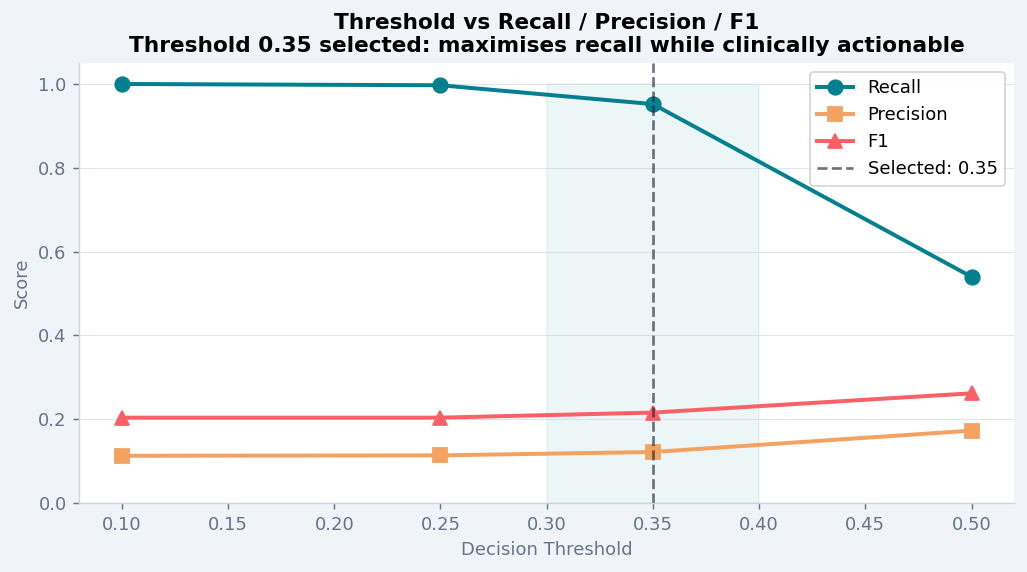

In [ ]:
y_val_proba = lr.predict_proba(X_val_scaled)[:, 1]

results = []
for t in [0.10, 0.25, 0.35, 0.50]:
    y_pred_t = (y_val_proba >= t).astype(int)
    results.append({
        'threshold': t,
        'recall':    round(recall_score(y_val, y_pred_t), 3),
        'precision': round(precision_score(y_val, y_pred_t), 3),
        'f1':        round(f1_score(y_val, y_pred_t), 3),
        'roc_auc':   round(roc_auc_score(y_val, y_val_proba), 3),
    })

threshold_df = pd.DataFrame(results)
print('Validation threshold analysis:')
print(threshold_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(threshold_df['threshold'], threshold_df['recall'],
        'o-', color='#028090', lw=2.2, ms=8, label='Recall')
ax.plot(threshold_df['threshold'], threshold_df['precision'],
        's-', color='#F4A261', lw=2.2, ms=8, label='Precision')
ax.plot(threshold_df['threshold'], threshold_df['f1'],
        '^-', color='#F96167', lw=2.2, ms=8, label='F1')
ax.axvline(0.35, ls='--', color='#0D1B2A', lw=1.5, alpha=0.6,
           label='Selected: 0.35')
ax.fill_betweenx([0,1], 0.30, 0.40, alpha=0.07, color='#028090')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Threshold vs Recall / Precision / F1\n'
             'Threshold 0.35 selected: maximises recall while clinically actionable',
             fontweight='bold')
ax.legend(frameon=True, fontsize=10)
ax.grid(axis='y', color='#CBD5E1', lw=0.5, alpha=0.7)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'lr_01_threshold.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6 — Full Evaluation on Test Set

=== Test Set Metrics (threshold=0.35) ===
  ROC-AUC               : 0.638
  PR-AUC                : 0.1968
  Recall                : 0.9533
  Precision             : 0.1221
  F1                    : 0.2165
  Balanced Accuracy     : 0.5384
  Brier Score           : 0.2324
  Log Loss              : 0.6611

                 precision    recall  f1-score   support

 Not Readmitted       0.95      0.12      0.22     17754
Readmitted <30d       0.12      0.95      0.22      2271

       accuracy                           0.22     20025
      macro avg       0.54      0.54      0.22     20025
   weighted avg       0.86      0.22      0.22     20025

TN=2,192  FP=15,562
FN=106  TP=2,165


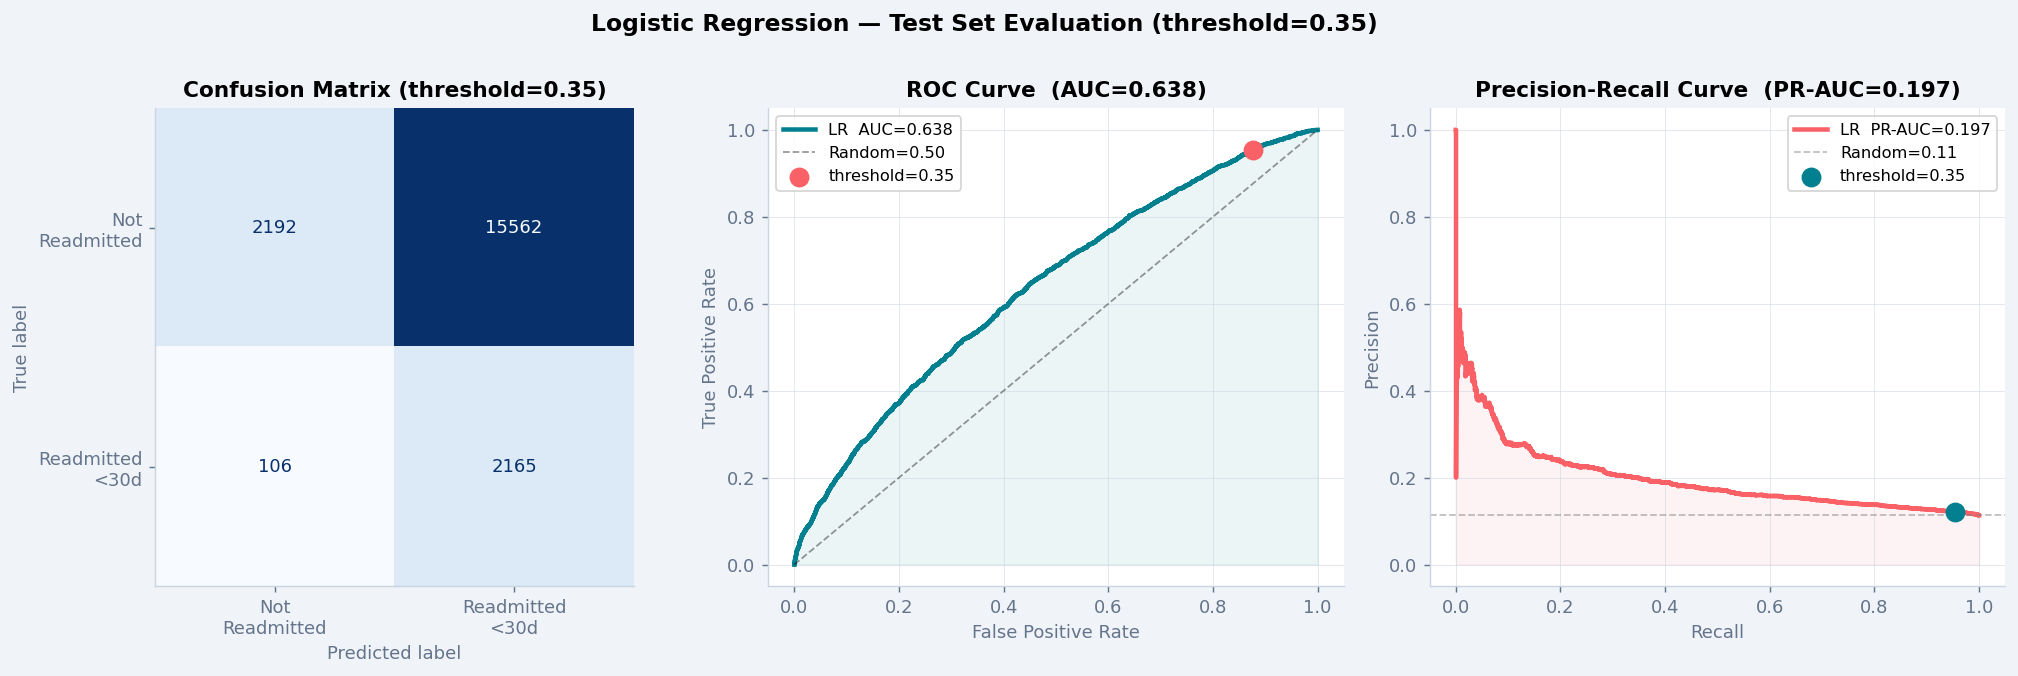

In [ ]:
THRESHOLD = 0.35
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
y_pred       = (y_pred_proba >= THRESHOLD).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────────
metrics = {
    'ROC-AUC':           round(roc_auc_score(y_test, y_pred_proba), 4),
    'PR-AUC':            round(average_precision_score(y_test, y_pred_proba), 4),
    'Recall':            round(recall_score(y_test, y_pred), 4),
    'Precision':         round(precision_score(y_test, y_pred), 4),
    'F1':                round(f1_score(y_test, y_pred), 4),
    'Balanced Accuracy': round(balanced_accuracy_score(y_test, y_pred), 4),
    'Brier Score':       round(brier_score_loss(y_test, y_pred_proba), 4),
    'Log Loss':          round(log_loss(y_test, y_pred_proba), 4),
}
print('=== Test Set Metrics (threshold=0.35) ===')
for k, v in metrics.items():
    print(f'  {k:<22}: {v}')

print('\n' + classification_report(
    y_test, y_pred,
    target_names=['Not Readmitted', 'Readmitted <30d']))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn:,}  FP={fp:,}')
print(f'FN={fn:,}  TP={tp:,}')

# ── Plots: CM + ROC + PR ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0],
    display_labels=['Not\nReadmitted', 'Readmitted\n<30d'],
    colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix (threshold=0.35)', fontweight='bold')

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#028090', lw=2.5,
             label=f'LR  AUC={metrics["ROC-AUC"]:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random=0.50')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#028090')
# Mark operating point at threshold=0.35
axes[1].scatter([fp/(fp+tn)],[tp/(tp+fn)],
                s=100,color='#F96167',zorder=5,label=f'threshold=0.35')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve  (AUC={metrics["ROC-AUC"]:.3f})', fontweight='bold')
axes[1].legend(fontsize=9,frameon=True)
axes[1].spines[['top','right']].set_visible(False)
axes[1].grid(color='#CBD5E1',lw=0.5,alpha=0.6)

# PR curve
prec_c, rec_c, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(rec_c, prec_c, color='#F96167', lw=2.5,
             label=f'LR  PR-AUC={metrics["PR-AUC"]:.3f}')
axes[2].axhline(y_test.mean(), ls='--', color='gray', lw=1,
                alpha=0.5, label=f'Random={y_test.mean():.2f}')
axes[2].scatter([metrics['Recall']],[metrics['Precision']],
                s=100,color='#028090',zorder=5,label=f'threshold=0.35')
axes[2].fill_between(rec_c, prec_c, alpha=0.07, color='#F96167')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title(f'Precision-Recall Curve  (PR-AUC={metrics["PR-AUC"]:.3f})',
                  fontweight='bold')
axes[2].legend(fontsize=9,frameon=True)
axes[2].spines[['top','right']].set_visible(False)
axes[2].grid(color='#CBD5E1',lw=0.5,alpha=0.6)

plt.suptitle('Logistic Regression — Test Set Evaluation (threshold=0.35)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,'lr_02_evaluation.png'), dpi=300, bbox_inches='tight')
plt.show()

## 7 — 5-Fold Cross-Validation

5-Fold CV Results:
  Fold 1: AUC = 0.6494
  Fold 2: AUC = 0.6394
  Fold 3: AUC = 0.6296
  Fold 4: AUC = 0.6465
  Fold 5: AUC = 0.6548

Mean AUC : 0.6440
Std  AUC : 0.0087  (low std = stable, no overfitting)


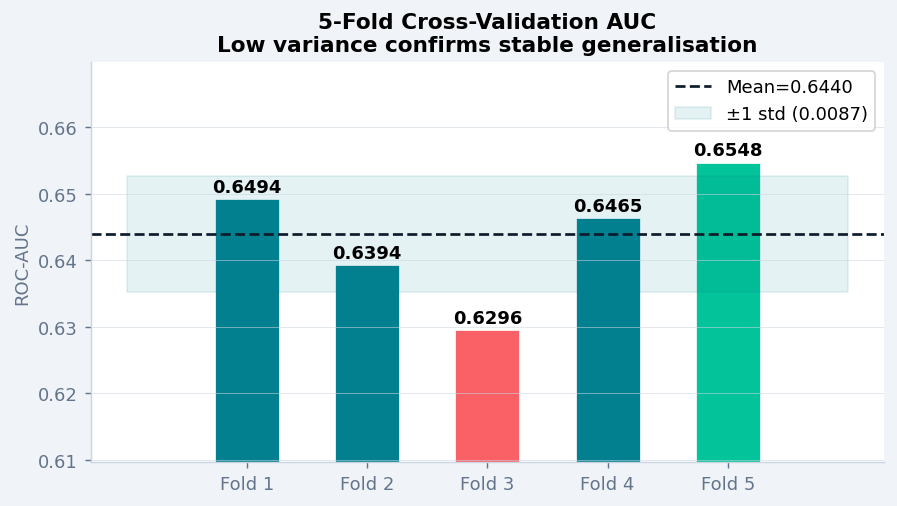

In [ ]:
# CV pipeline: scaler inside each fold to prevent leakage
cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(C=0.1, class_weight='balanced',
                                   max_iter=1000, solver='lbfgs', random_state=42))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs = cross_val_score(
    cv_pipeline, X_train, y_train,
    scoring='roc_auc', cv=cv, n_jobs=-1)

print('5-Fold CV Results:')
for i, auc in enumerate(cv_aucs, 1):
    print(f'  Fold {i}: AUC = {auc:.4f}')
print(f'\nMean AUC : {cv_aucs.mean():.4f}')
print(f'Std  AUC : {cv_aucs.std():.4f}  (low std = stable, no overfitting)')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7,4))
bar_colors = ['#F96167' if a < cv_aucs.mean() - cv_aucs.std() else
              '#02C39A' if a > cv_aucs.mean() + cv_aucs.std() else
              '#028090' for a in cv_aucs]
bars = ax.bar([f'Fold {i}' for i in range(1,6)], cv_aucs,
              color=bar_colors, edgecolor='white', lw=1.5, width=0.55)
for bar, val in zip(bars, cv_aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(cv_aucs.mean(), ls='--', color='#0D1B2A', lw=1.5,
           label=f'Mean={cv_aucs.mean():.4f}')
ax.fill_between(range(-1,6),
                cv_aucs.mean()-cv_aucs.std(),
                cv_aucs.mean()+cv_aucs.std(),
                alpha=0.1, color='#028090',
                label=f'±1 std ({cv_aucs.std():.4f})')
ax.set_ylim(cv_aucs.min()-0.02, cv_aucs.max()+0.015)
ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold Cross-Validation AUC\nLow variance confirms stable generalisation',
             fontweight='bold')
ax.legend(frameon=True, fontsize=10)
ax.grid(axis='y', color='#CBD5E1', lw=0.5, alpha=0.6)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,'lr_03_cv.png'), dpi=300, bbox_inches='tight')
plt.show()

## 8 — Feature Importance: Coefficients + SHAP

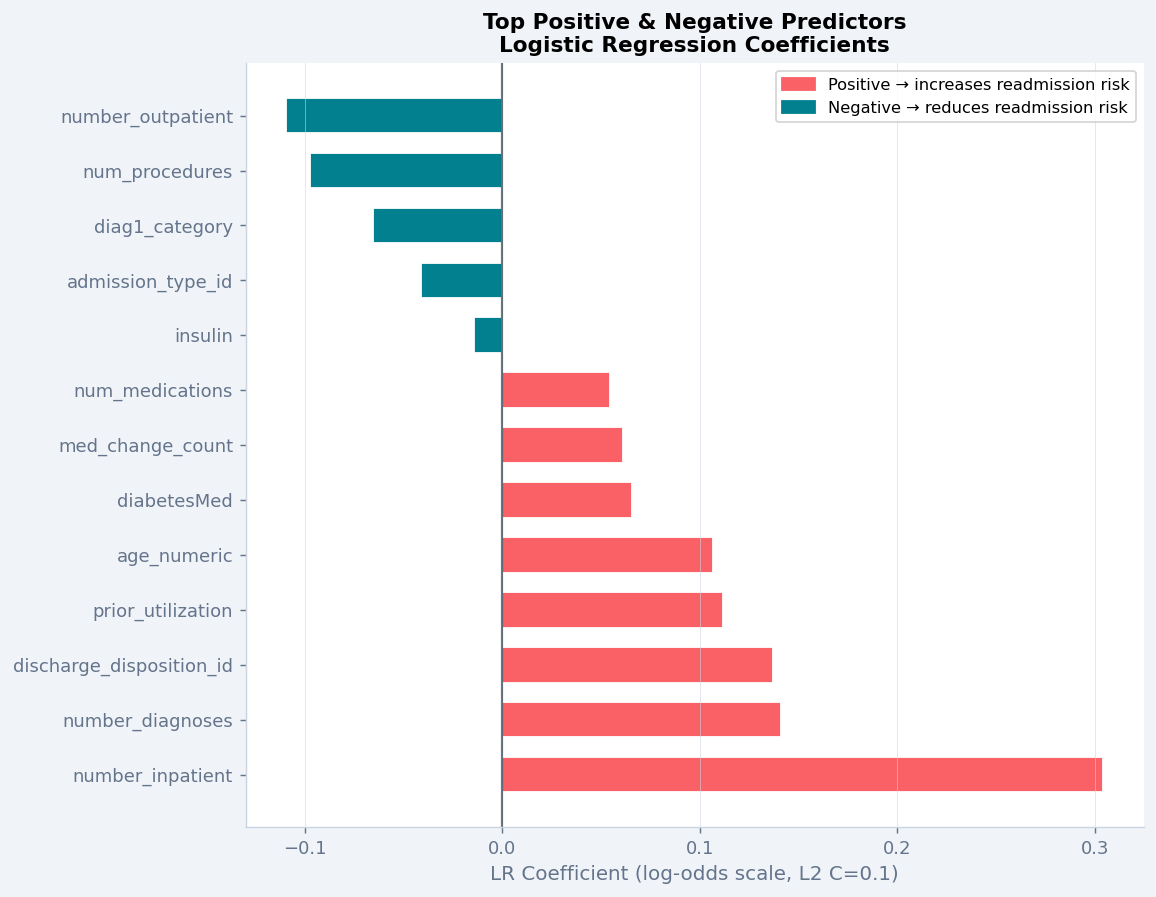

Top positive predictors:
                 feature  coefficient
        number_inpatient     0.304133
        number_diagnoses     0.141325
discharge_disposition_id     0.137237
       prior_utilization     0.111516
             age_numeric     0.106704
             diabetesMed     0.065444
        med_change_count     0.061314
         num_medications     0.054777

Top negative predictors:
          feature  coefficient
          insulin    -0.014416
admission_type_id    -0.041205
   diag1_category    -0.065313
   num_procedures    -0.097369
number_outpatient    -0.109170


In [ ]:
# ── LR Coefficients ───────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'feature':     X.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

top_pos = coef_df.head(8)
top_neg = coef_df.tail(5)
plot_df = pd.concat([top_pos, top_neg])
plot_df.to_csv(os.path.join(save_dir,'feature_importance.csv'), index=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors_coef = ['#F96167' if c > 0 else '#028090' for c in plot_df['coefficient']]
ax.barh(plot_df['feature'], plot_df['coefficient'],
        color=colors_coef, edgecolor='white', height=0.65)
ax.axvline(0, color='#0D1B2A', lw=1.2, alpha=0.6)
ax.set_xlabel('LR Coefficient (log-odds scale, L2 C=0.1)', fontsize=11)
ax.set_title('Top Positive & Negative Predictors\n'
             'Logistic Regression Coefficients', fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#F96167', label='Positive → increases readmission risk'),
    mpatches.Patch(color='#028090', label='Negative → reduces readmission risk'),
]
ax.legend(handles=legend_patches, frameon=True, fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', color='#CBD5E1', lw=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,'lr_04_coefficients.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Top positive predictors:')
print(top_pos[['feature','coefficient']].to_string(index=False))
print('\nTop negative predictors:')
print(top_neg[['feature','coefficient']].to_string(index=False))

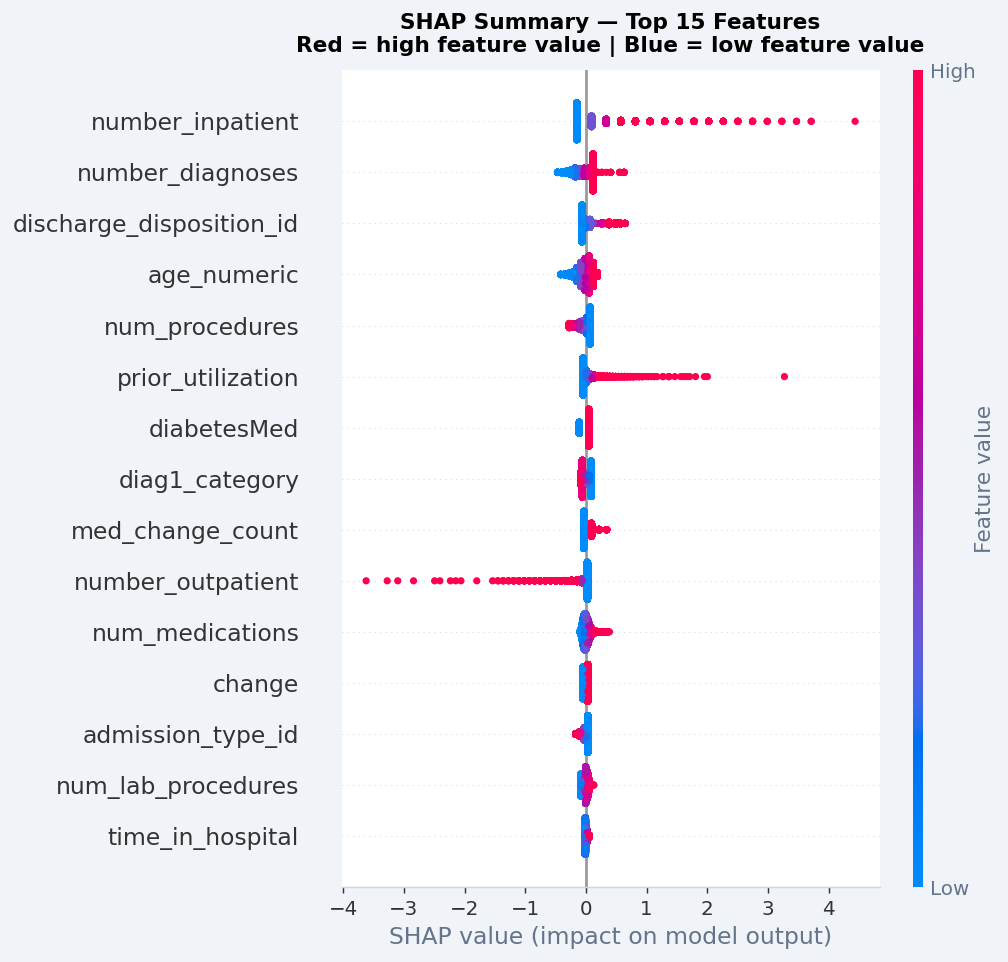

Top 10 by mean |SHAP|:
                 feature  mean_abs_shap
        number_inpatient       0.201673
        number_diagnoses       0.122315
discharge_disposition_id       0.088161
             age_numeric       0.085038
          num_procedures       0.076180
       prior_utilization       0.063397
             diabetesMed       0.061064
          diag1_category       0.060601
        med_change_count       0.052012
       number_outpatient       0.048433


In [ ]:
# ── SHAP ──────────────────────────────────────────────────────────────────────
# SHAP shows per-prediction feature contributions, accounting for
# feature value distributions — more informative than raw coefficients alone
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

explainer   = shap.Explainer(lr, X_train_df)
shap_values = explainer(X_test_df)

# Summary beeswarm
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, show=False, max_display=15)
plt.title('SHAP Summary — Top 15 Features\n'
          'Red = high feature value | Blue = low feature value',
          fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(os.path.join(save_dir,'lr_05_shap.png'), dpi=300, bbox_inches='tight')
plt.show()

# Feature importance by mean |SHAP|
shap_imp = pd.DataFrame({
    'feature':       X.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Top 10 by mean |SHAP|:')
print(shap_imp.head(10).to_string(index=False))